In [19]:
import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv", index_col=0)
X_val   = pd.read_csv("../data/processed/X_val.csv", index_col=0)
X_test  = pd.read_csv("../data/processed/X_test.csv", index_col=0)

In [20]:
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_val = pd.read_csv("../data/processed/y_val.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [21]:
from sklearn.ensemble import HistGradientBoostingClassifier
model = HistGradientBoostingClassifier(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_val_pred = model.predict(X_val)

In [22]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred, average="macro"))

Accuracy: 0.8297026858811701
Balanced Accuracy: 0.7113465671678993
F1 Score: 0.5637821884703244


In [23]:
from sklearn.metrics import classification_report
classification_report(y_val, y_val_pred)
print(classification_report(y_val, y_val_pred))

                    precision    recall  f1-score   support

         ascending       0.40      0.70      0.51       263
           central       0.85      0.72      0.78      4857
        descending       0.18      0.68      0.29       196
         endocrine       0.55      0.50      0.52        12
             motor       0.56      0.56      0.56        16
             optic       0.98      0.87      0.92     11680
           sensory       0.92      0.89      0.91      2540
 sensory_ascending       0.21      0.72      0.32        92
visual_centrifugal       0.14      0.65      0.23        78
 visual_projection       0.46      0.81      0.59      1153

          accuracy                           0.83     20887
         macro avg       0.53      0.71      0.56     20887
      weighted avg       0.89      0.83      0.85     20887



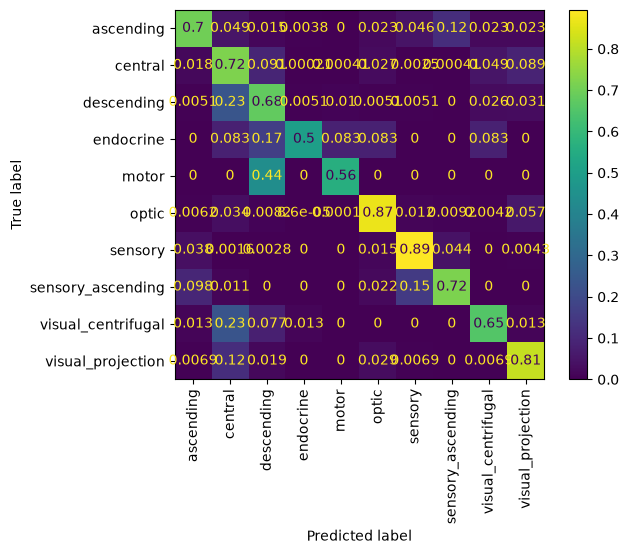

In [24]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, normalize="true", xticks_rotation=90)

os.makedirs("../results", exist_ok=True)
plt.gcf().savefig("../results/confusion_boosting_v1.png", dpi=150, bbox_inches="tight")

In [25]:
X_train = pd.read_csv("../data/processed/X_train_np.csv", index_col=0)
X_val   = pd.read_csv("../data/processed/X_val_np.csv", index_col=0)
X_test  = pd.read_csv("../data/processed/X_test_np.csv", index_col=0)

In [26]:
model_np = HistGradientBoostingClassifier(class_weight="balanced", max_iter=1000, random_state=42)
model_np.fit(X_train, y_train)
y_val_pred_np = model_np.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_val_pred_np))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_val_pred_np))
print("F1 Score:", f1_score(y_val, y_val_pred_np, average="macro"))
print(classification_report(y_val, y_val_pred_np))

Accuracy: 0.978120361947623
Balanced Accuracy: 0.8931018901306775
F1 Score: 0.8535599186782685
                    precision    recall  f1-score   support

         ascending       0.72      0.84      0.78       263
           central       0.99      0.97      0.98      4857
        descending       0.59      0.93      0.72       196
         endocrine       0.90      0.75      0.82        12
             motor       0.79      0.69      0.73        16
             optic       1.00      0.99      0.99     11680
           sensory       0.97      0.96      0.97      2540
 sensory_ascending       0.50      0.84      0.62        92
visual_centrifugal       0.92      0.97      0.94        78
 visual_projection       0.96      0.98      0.97      1153

          accuracy                           0.98     20887
         macro avg       0.83      0.89      0.85     20887
      weighted avg       0.98      0.98      0.98     20887



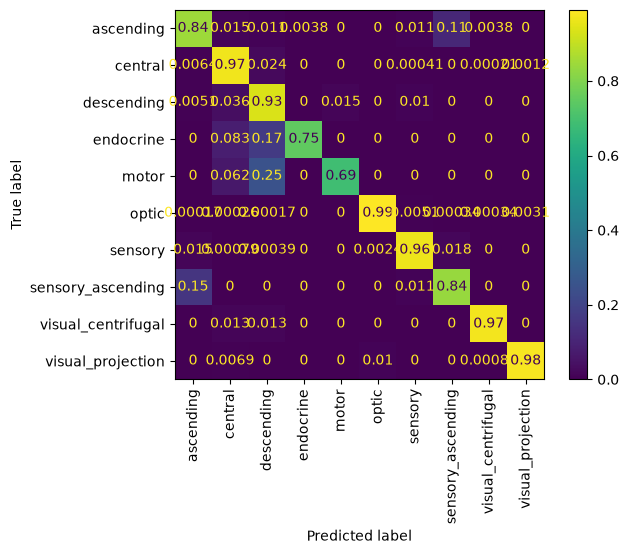

In [27]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_np, normalize="true", xticks_rotation=90)

os.makedirs("../results", exist_ok=True)
plt.gcf().savefig("../results/confusion_boosting_v1.png", dpi=150, bbox_inches="tight")

In [28]:
y_test_pred = model_np.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred, average="macro"))
print(classification_report(y_test, y_test_pred))

Accuracy: 0.9770670752142481
Balanced Accuracy: 0.8798689763864243
F1 Score: 0.8432488000620163
                    precision    recall  f1-score   support

         ascending       0.73      0.85      0.79       262
           central       0.99      0.97      0.98      4857
        descending       0.58      0.90      0.70       195
         endocrine       0.73      0.67      0.70        12
             motor       0.87      0.76      0.81        17
             optic       1.00      0.99      0.99     11680
           sensory       0.97      0.97      0.97      2541
 sensory_ascending       0.52      0.74      0.61        92
visual_centrifugal       0.87      0.97      0.92        79
 visual_projection       0.96      0.98      0.97      1152

          accuracy                           0.98     20887
         macro avg       0.82      0.88      0.84     20887
      weighted avg       0.98      0.98      0.98     20887



## Gradient Boosting results

On the validation set, with `HistGradientBoostingClassifier(class_weight="balanced")`:

- Accuracy: 0.830
- Balanced accuracy: 0.711
- Macro F1: 0.564

An earlier run of this notebook, without class weights, gave accuracy 0.873, balanced accuracy 0.524 and macro F1 0.507. Without weights the model optimises mostly for the large classes, so accuracy is higher but it recovers few rare-class neurons; `class_weight="balanced"` makes rare-class errors cost more, trading about 4 points of accuracy for a much higher balanced accuracy (+0.19) and macro F1 (+0.06).

Compared to the Logistic Regression baseline (accuracy 0.683, balanced accuracy 0.676, macro F1 0.374), balanced boosting is better on all three metrics. (The unweighted run was better than LR on accuracy and macro F1 but worse on balanced accuracy.) Recall of the rare classes went up with the weights (e.g. `visual_projection` 0.45 → 0.81, `descending` 0.20 → 0.68, `visual_centrifugal` 0.27 → 0.65, `sensory_ascending` 0.34 → 0.72) but their precision dropped (e.g. `descending` 0.35 → 0.18, `visual_centrifugal` 0.23 → 0.14): the model now over-predicts them.

The confusion-matrix errors below are from the earlier **unweighted** run; the saved `confusion_boosting_v1.png` shows the balanced model.

- `visual_projection` → `central` 31%, → `optic` 22%
- `descending` → `central` 62%
- `visual_centrifugal` → `central` 63%
- `sensory_ascending` → `sensory` 49%

These are not random mistakes: in every case, the misclassified class is one whose definition depends on **where in the brain the neuron projects to or from** (e.g. descending, visual-centrifugal, ascending), and it gets absorbed into a broad, location-agnostic class (`central`, `optic`, `sensory`). The current features (partner counts, synapse counts, size, output neurotransmitter mix) carry no information about *which brain region* a neuron connects to — only *how much* it connects. The natural next step is adding features that capture synapses per neuropil, so the model has a chance to distinguish neurons by their spatial connectivity pattern, not just its magnitude.

## Υποθέσεις για τα neuropil features

Πριν τρέξω το μοντέλο με τα νέα features (X_*_np.csv), αυτές είναι οι
υποθέσεις μου για τις κλάσεις με χαμηλό F1:

- **Descending (F1 = 0.29):** [γράψε εδώ πού θα είναι τα in_ και τα out_]
- **Visual centrifugal:** οι είσοδοι (in_) θα είναι σε περιοχές του κεντρικού
  εγκεφάλου και οι έξοδοι (out_) σε περιοχές του οπτικού λοβού (ME, LO, LOP).
- **Motor:** πολύ λίγες ή καθόλου έξοδοι μέσα στον εγκέφαλο, γιατί η έξοδός
  τους πηγαίνει στους μύες. (προσοχή: μικρό support, 16 και 12 νευρώνες, το F1 είναι ασταθές)
- **Endocrine:** λίγες συναπτικές έξοδοι, γιατί απελευθερώνουν ορμόνες στο
  αίμα και όχι σε συγκεκριμένους νευρώνες. (προσοχή: μικρό support, 16 και 12 νευρώνες, το F1 είναι ασταθές)

**Baseline (πριν τα νέα features):** macro F1 = 0.564, balanced accuracy = 0.711, accuracy = 0.830